In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("saudi_real_estate_sale.csv")

In [3]:
pd.set_option('display.max_columns', None)
data.sample(5)

,id,createdAt,month,week_day,property_category,beds,livings,wc,area,street_width,age,ketchen,location.lat,location.lng,province,city_id,city,city_en,district_id,district,district_en,price,price_per_m2,total_rooms,is_riyadh,is_new
84534,4802957,2023-01-01,Jan,Sun,Villa,6.0,1.0,5.0,240.0,12.0,0.0,1.0,26.332731,43.935108,Qasim,52,بريدة,Buraydah,2292,حي الخبيبية,Al Khubaybia neighborhood,730000.0,3041.666667,12.0,0,1
289168,5388223,2023-06-05,Jun,Mon,Villa,6.5,3.0,5.0,280.0,20.0,0.0,1.0,24.559578,46.517620,Riyadh,21,الرياض,Riyadh,682,حي طويق,Tuwaiq neighborhood,1100000.0,3928.571429,14.5,1,1
4931,3662694,2023-01-01,Jan,Sun,House,5.0,2.0,4.0,378.0,24.0,2.5,1.0,24.154112,47.336971,Riyadh,13,الخرج,Al Kharj,292,حي النهضة,Al Nahda neighborhood,250000.0,661.375661,11.0,0,0
136111,4978866,2023-01-01,Jan,Sun,Villa,5.0,2.0,5.0,300.0,20.0,0.0,1.0,24.544974,46.519695,Riyadh,21,الرياض,Riyadh,682,حي طويق,Tuwaiq neighborhood,1320000.0,4400.000000,12.0,1,1
180057,5096738,2023-02-02,Feb,Thu,Villa,5.0,1.0,5.0,600.0,15.0,0.0,1.0,24.764794,46.619161,Riyadh,21,الرياض,Riyadh,664,حي حطين,Hittin neighborhood,4080000.0,6800.000000,11.0,1,1


In [4]:
data["property_category"].unique()

array(['Villa', 'Building', 'Apartment', 'House', 'Floor'], dtype=object)

In [5]:
for column in data.columns:
    print("=" * 60)
    
    print("=" * 60)
    
    counts = data[column].value_counts(dropna=False)   
    
    print(counts)
    print("\n")

id
14155      1
24578      1
24582      1
40278      1
50786      1
          ..
5461528    1
5461567    1
5461569    1
5461592    1
5461602    1
Name: count, Length: 307706, dtype: int64


createdAt
2023-01-01    161298
2023-03-02     31057
2023-02-02     25672
2023-03-31     23552
2023-05-03     18804
2023-06-05     15234
2023-06-04     13631
2023-07-07      8612
2023-04-01      3548
2023-05-14      3024
2023-01-04      1365
2023-01-03      1249
2023-01-02       660
Name: count, dtype: int64


month
Jan    164572
Mar     54609
Jun     28865
Feb     25672
May     21828
Jul      8612
Apr      3548
Name: count, dtype: int64


week_day
Sun    177953
Thu     56729
Fri     32164
Wed     20169
Mon     15894
Sat      3548
Tue      1249
Name: count, dtype: int64


property_category
Villa        187200
Apartment     82178
Building      24636
Floor          9783
House          3909
Name: count, dtype: int64


beds
5.0    127672
4.0     70750
3.0     31893
6.5     28090
2.5     27820
6.0     207

In [6]:
data.describe()

,id,beds,livings,wc,area,street_width,age,ketchen,location.lat,location.lng,city_id,district_id,price,price_per_m2,total_rooms,is_riyadh,is_new
count,3.077060e+05,307706.000000,307706.000000,307706.000000,307706.000000,307706.000000,307706.000000,307706.000000,307706.000000,307706.000000,307706.000000,307706.000000,3.077060e+05,3.077060e+05,307706.000000,307706.000000,307706.000000
mean,4.934781e+06,4.539257,1.831735,3.961731,327.728091,19.979255,0.600646,0.904886,23.952703,44.888270,35.152834,1622.563343,1.613389e+06,5.044073e+03,10.332723,0.497605,0.764281
std,4.286265e+05,1.128210,1.122578,1.210396,158.065840,6.870384,1.049824,0.292076,2.100624,3.773828,23.300830,1336.950939,1.118032e+06,1.516207e+04,2.874994,0.499995,0.424448
min,1.415500e+04,2.500000,0.000000,1.000000,1.000000,3.000000,0.000000,0.000000,-30.488082,-2.074926,1.000000,6.000000,1.000000e+00,1.453488e-03,3.500000,0.000000,0.000000
25%,4.766584e+06,4.000000,1.000000,3.000000,208.000000,15.000000,0.000000,1.000000,21.778863,39.832558,21.000000,588.000000,7.800000e+05,3.275109e+03,9.000000,0.000000,1.000000
50%,5.027680e+06,5.000000,2.000000,4.000000,300.000000,20.000000,0.000000,1.000000,24.650337,46.611846,21.000000,698.000000,1.200000e+06,4.304636e+03,11.000000,0.000000,1.000000
75%,5.225642e+06,5.000000,3.000000,5.000000,400.000000,23.000000,1.000000,1.000000,24.858625,46.775084,66.000000,3476.000000,2.100000e+06,5.930233e+03,12.000000,1.000000,1.000000
max,5.461602e+06,6.500000,6.000000,5.000000,688.000000,35.000000,2.500000,1.000000,37.506038,51.232361,97.000000,4436.000000,4.080000e+06,4.080000e+06,17.500000,1.000000,1.000000


In [7]:
data.shape

(307706, 26)

In [8]:
data.isnull().sum()

id                   0
createdAt            0
month                0
week_day             0
property_category    0
beds                 0
livings              0
wc                   0
area                 0
street_width         0
age                  0
ketchen              0
location.lat         0
location.lng         0
province             0
city_id              0
city                 0
city_en              0
district_id          0
district             0
district_en          0
price                0
price_per_m2         0
total_rooms          0
is_riyadh            0
is_new               0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307706 entries, 0 to 307705
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 307706 non-null  int64  
 1   createdAt          307706 non-null  object 
 2   month              307706 non-null  object 
 3   week_day           307706 non-null  object 
 4   property_category  307706 non-null  object 
 5   beds               307706 non-null  float64
 6   livings            307706 non-null  float64
 7   wc                 307706 non-null  float64
 8   area               307706 non-null  float64
 9   street_width       307706 non-null  float64
 10  age                307706 non-null  float64
 11  ketchen            307706 non-null  float64
 12  location.lat       307706 non-null  float64
 13  location.lng       307706 non-null  float64
 14  province           307706 non-null  object 
 15  city_id            307706 non-null  int64  
 16  ci

In [11]:
data['city'].unique()

array(['جدة', 'مكة المكرمة', 'الدمام', 'مدينة الملك عبدالله الاقتصادية',
       'الطائف', 'الدرعية', 'الرياض', 'المدينة المنورة', 'بريدة', 'الخبر',
       'الخرج', 'الهفوف', 'ينبع', 'ابها', 'الظهران', 'الزلفي', 'عرعر',
       'رياض الخبراء', 'محايل', 'راس تنورة', 'الجبيل', 'تبوك',
       'خميس مشيط', 'المجمعة', 'النعيرية', 'سكاكا', 'القويعية', 'رابغ',
       'عنيزة', 'عفيف', 'حفر الباطن', 'المزاحمية', 'حائل', 'البكيرية',
       'بللسمر', 'الرس', 'تربه', 'حوطة بني تميم', 'ابو عريش', 'بيش',
       'الباحة', 'الجموم', 'احد المسارحة', 'سيهات', 'جازان', 'ثول',
       'البدائع', 'بقعاء', 'الدوادمي', 'الخفجي', 'المذنب', 'مهد الذهب',
       'القنفذة', 'ثادق', 'الدلم', 'الغاط', 'الليث', 'صبيا', 'بقيق',
       'شقراء', 'النبهانية', 'الحريق', 'صفوى', 'الهياثم', 'المجاردة',
       'بدر', 'خيبر', 'السليل', 'رفحاء', 'بيشة', 'رماح', 'احد رفيده',
       'الشماسية', 'صامطة', 'الوجه', 'شرورة', 'نجران', 'الخرمة', 'تيماء',
       'عنك', 'الحناكية', 'تاروت', 'املج', 'الغزالة', 'طريف', 'العلا',
       'القط

In [12]:
Data_cor=data.corr(numeric_only=True)

In [13]:
Data_cor

,id,beds,livings,wc,area,street_width,age,ketchen,location.lat,location.lng,city_id,district_id,price,price_per_m2,total_rooms,is_riyadh,is_new
id,1.000000,-0.015878,0.011508,0.014806,-0.046754,-0.013781,-0.028372,0.053425,-0.035247,-0.030357,0.006442,0.000257,-0.006357,0.012175,0.004496,0.036079,0.029298
beds,-0.015878,1.000000,0.399240,0.614633,0.015427,-0.144273,-0.170161,0.253461,-0.067198,-0.041885,0.044714,0.068084,-0.029623,-0.012085,0.807076,-0.082824,0.167363
livings,0.011508,0.399240,1.000000,0.580508,0.118532,-0.114435,-0.073888,0.294335,0.119197,0.196604,-0.204451,-0.228613,0.219318,0.029456,0.791532,0.236533,0.070593
wc,0.014806,0.614633,0.580508,1.000000,0.008810,-0.181050,-0.240469,0.364315,0.080808,0.150245,-0.144094,-0.162826,0.060917,0.014006,0.888871,0.150655,0.235681
area,-0.046754,0.015427,0.118532,0.008810,1.000000,-0.016544,0.418405,-0.132503,0.106841,0.115952,-0.121235,-0.157586,0.672718,-0.016563,0.056045,0.121778,-0.416448
street_width,-0.013781,-0.144273,-0.114435,-0.181050,-0.016544,1.000000,-0.022682,-0.037858,0.055657,0.065207,-0.052075,-0.043610,-0.026304,-0.011649,-0.177522,0.025002,0.023447
age,-0.028372,-0.170161,-0.073888,-0.240469,0.418405,-0.022682,1.000000,-0.153277,0.114744,0.087153,-0.089387,-0.129819,0.324638,0.014181,-0.196864,0.124002,-0.990836
ketchen,0.053425,0.253461,0.294335,0.364315,-0.132503,-0.037858,-0.153277,1.000000,0.021042,0.069073,-0.070325,-0.094268,-0.037859,0.003557,0.367770,0.123873,0.151186
location.lat,-0.035247,-0.067198,0.119197,0.080808,0.106841,0.055657,0.114744,0.021042,1.000000,0.744054,-0.609207,-0.675071,0.158990,0.021115,0.054193,0.363159,-0.116157
location.lng,-0.030357,-0.041885,0.196604,0.150245,0.115952,0.065207,0.087153,0.069073,0.744054,1.000000,-0.821949,-0.841121,0.175087,0.021015,0.123584,0.470084,-0.089831


<Axes: >

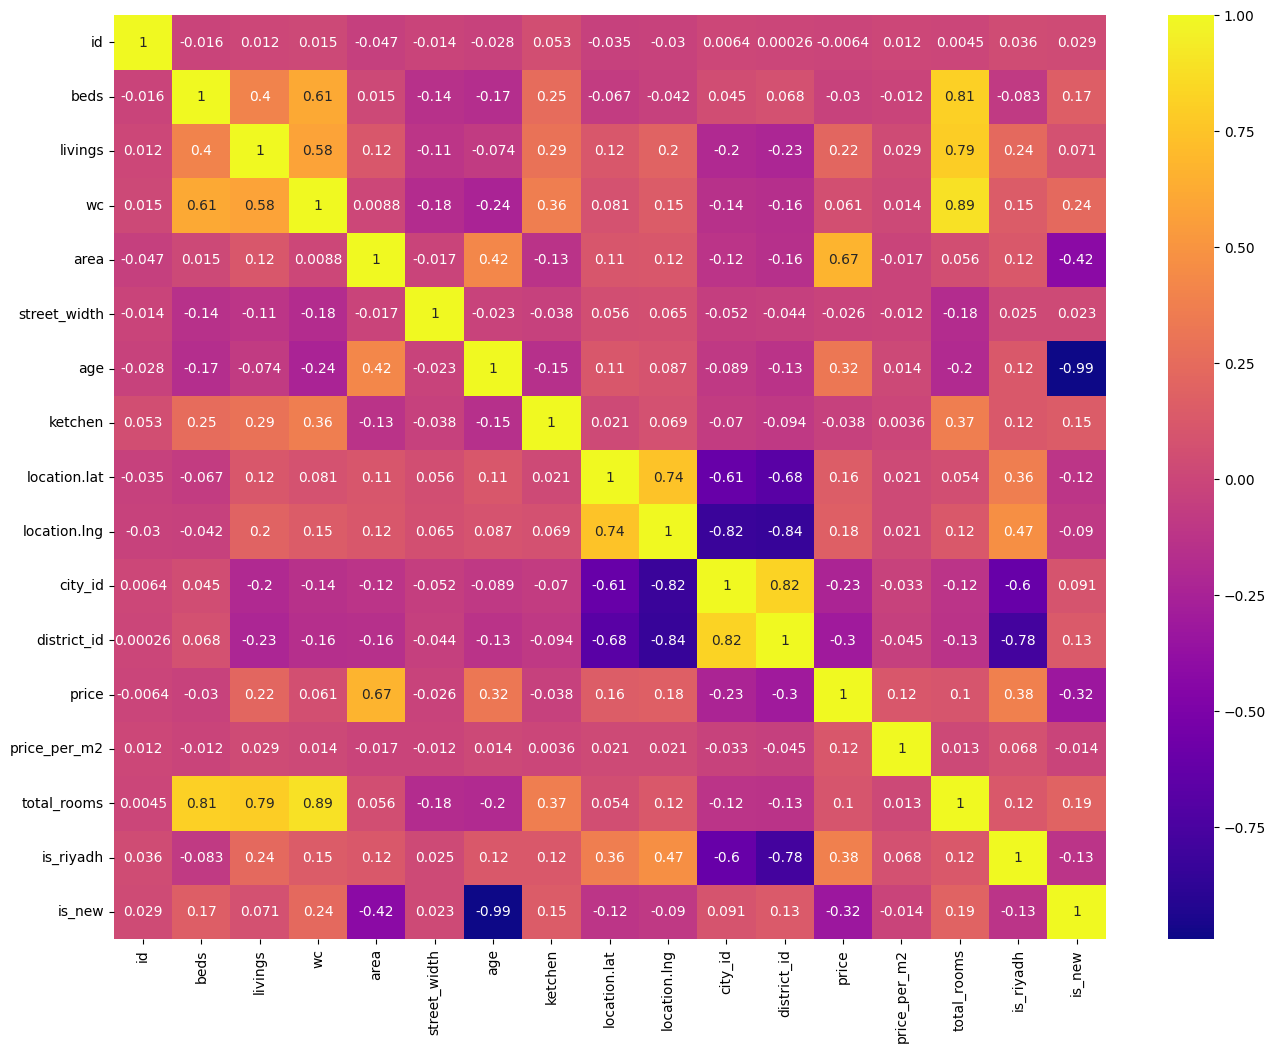

In [14]:
plt.figure(figsize=(16, 12))
sns.heatmap(Data_cor,annot=True,cmap='plasma')

C:\Users\DeLL\AppData\Local\Temp\ipykernel_5852\3697311660.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data['price_per_m2'],orient="v",palette='husl',width=0.7)


<Axes: ylabel='price_per_m2'>

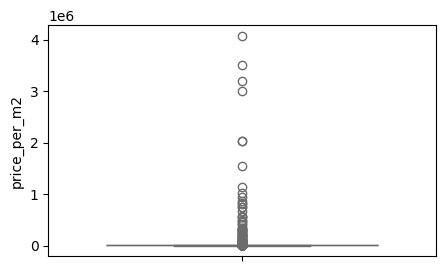

In [15]:
plt.figure(figsize=(5, 3))
sns.boxplot(data=data['price_per_m2'],orient="v",palette='husl',width=0.7)

In [16]:
column = 'price_per_m2'  

Q1 = data[column].quantile(0.25)
Q3 = data[column].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

print('num of outliers',len(outliers))
print(f" outliers %: {len(outliers)/len(data)*100:.2f}%")


num of outliers 14043
 outliers %: 4.56%


In [17]:
data.sample(1)

,id,createdAt,month,week_day,property_category,beds,livings,wc,area,street_width,age,ketchen,location.lat,location.lng,province,city_id,city,city_en,district_id,district,district_en,price,price_per_m2,total_rooms,is_riyadh,is_new
126694,4949435,2023-01-01,Jan,Sun,Villa,5.0,2.0,5.0,270.0,20.0,0.0,1.0,26.143338,50.145603,Eastern,12,الخبر,Khobar,1044,حي الامواج,Al Amwaj neighborhood,800000.0,2962.962963,12.0,0,1


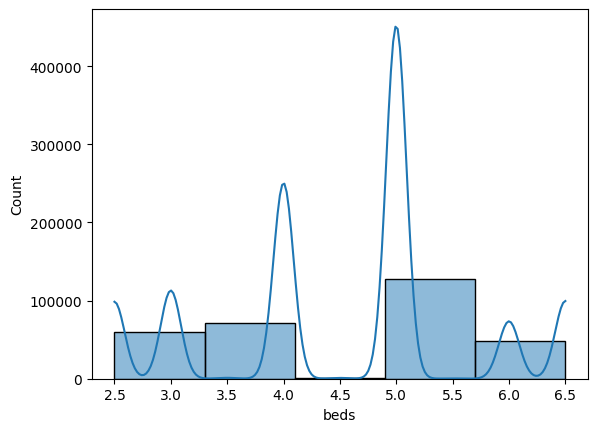

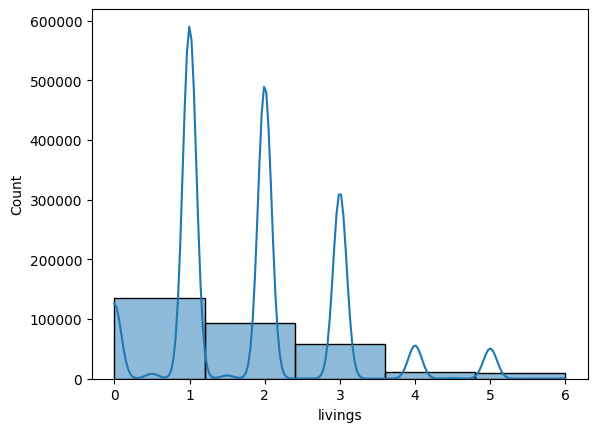

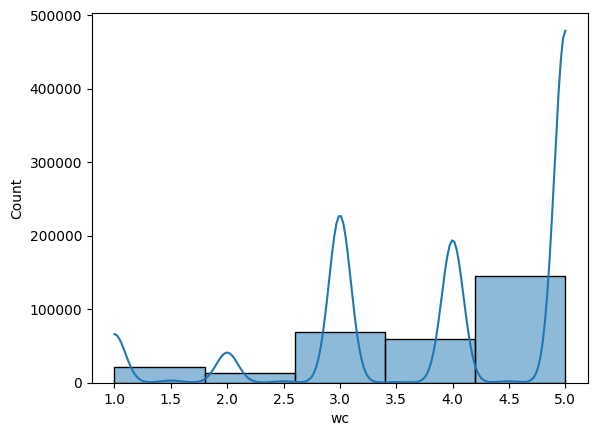

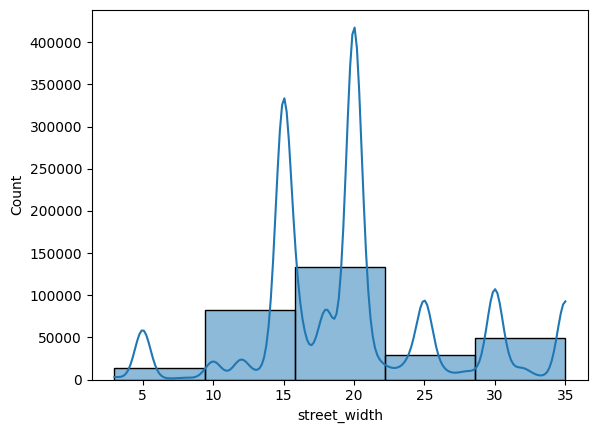

In [18]:
column_for_dist=['beds','livings','wc','street_width']
for i in data[column_for_dist]:
    sns.histplot(data[i],bins=5,kde=True)
    plt.show()

In [19]:
data.sample()

,id,createdAt,month,week_day,property_category,beds,livings,wc,area,street_width,age,ketchen,location.lat,location.lng,province,city_id,city,city_en,district_id,district,district_en,price,price_per_m2,total_rooms,is_riyadh,is_new
44043,4550425,2023-01-01,Jan,Sun,Villa,5.0,2.0,5.0,273.0,15.0,0.0,1.0,24.556258,46.803486,Riyadh,21,الرياض,Riyadh,684,حي طيبة,Taybah neighborhood,890000.0,3260.07326,12.0,1,1


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = ["beds", "livings", "wc", "area", 
                    "street_width", "ketchen", "total_rooms"]   

categorical_features = [ "city", "district"]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_features),           
        ('cat', OneHotEncoder(handle_unknown='ignore', 
                              sparse_output=False), categorical_features)
    ])



In [21]:
X = data[numeric_features + categorical_features]
Y = data['price']                     





In [22]:
X.sample()

,beds,livings,wc,area,street_width,ketchen,total_rooms,city,district
254029,5.0,2.0,5.0,348.0,35.0,1.0,12.0,الرياض,حي نمار


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [24]:
data['property_category'] = data['property_category'].astype('category').cat.codes

features = ['beds', 'livings', 'wc', 'area', 'street_width', 'age', 'ketchen', 
            'property_category', 'is_riyadh', 'is_new', 'location.lat', 'location.lng']



In [25]:
X = data[features]
y = np.log1p(data['price']) 


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [27]:
y_pred_log = model.predict(X_test)
y_pred_actual = np.expm1(y_pred_log) 
y_test_actual = np.expm1(y_test)

print(f"R2 Score: {r2_score(y_test_actual, y_pred_actual):.4f}")
print(f"MAE (Error in Rial): {mean_absolute_error(y_test_actual, y_pred_actual):,.2f}")

R2 Score: 0.9084
MAE (Error in Rial): 167,930.90


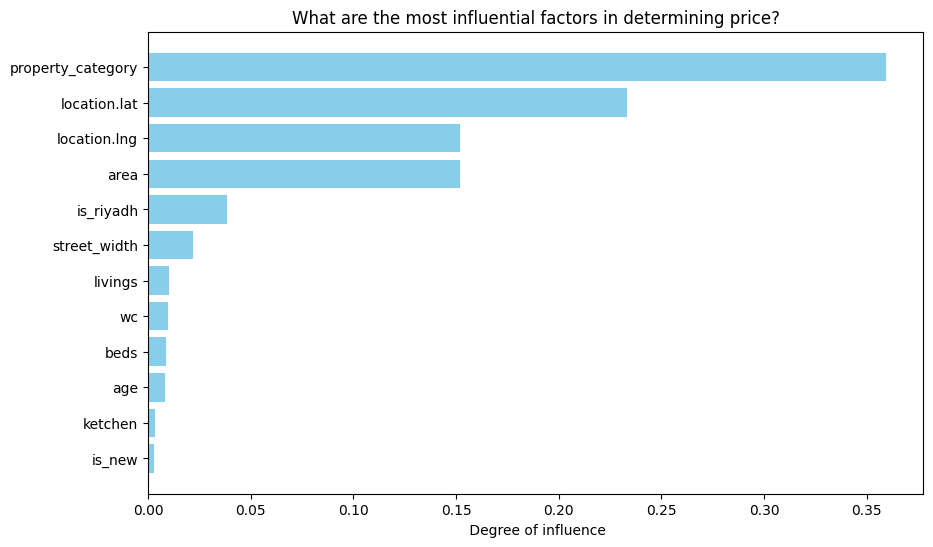

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('What are the most influential factors in determining price?')
plt.xlabel(' Degree of influence')
plt.show()

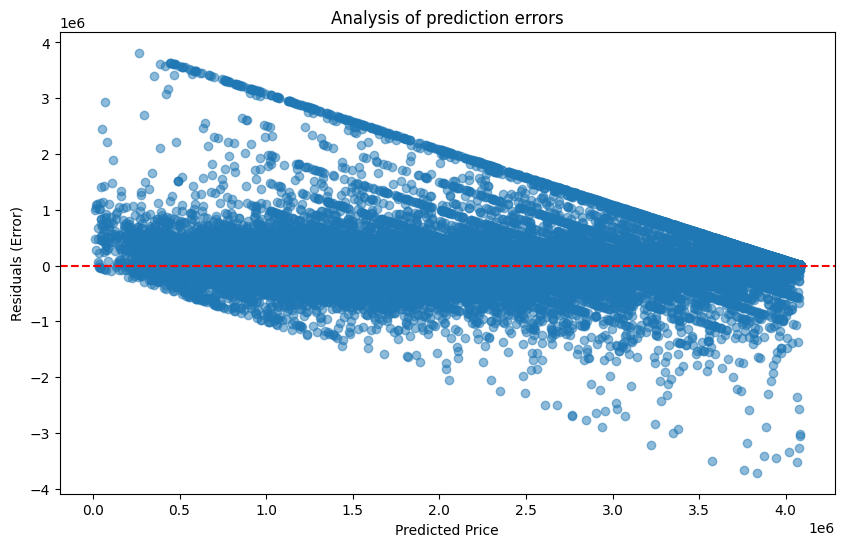

In [32]:
residuals = y_test_actual - y_pred_actual

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_actual, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Error)')
plt.title('Analysis of prediction errors')
plt.show()

C:\Users\DeLL\AppData\Local\Temp\ipykernel_5852\2984398004.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(y_test_actual, label='Actual Price', color='blue', shade=True)
C:\Users\DeLL\AppData\Local\Temp\ipykernel_5852\2984398004.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(y_pred_actual, label='Predicted Price', color='orange', shade=True)


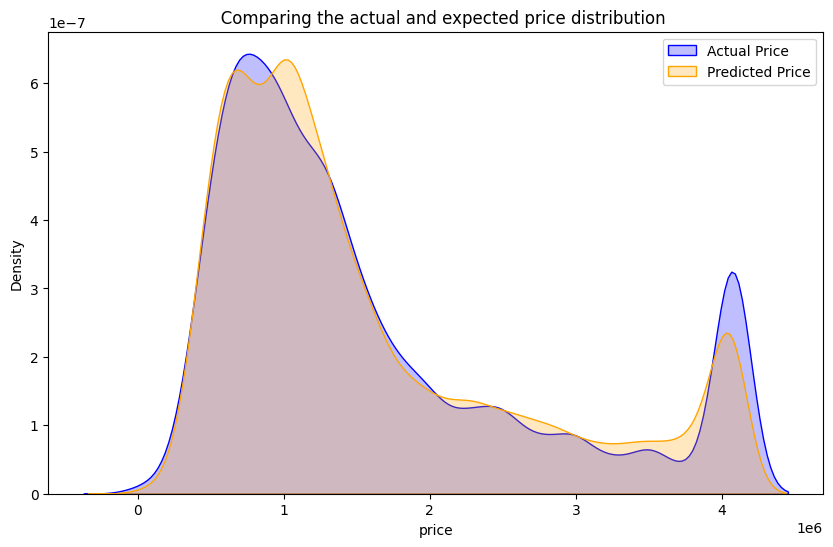

In [33]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(y_test_actual, label='Actual Price', color='blue', shade=True)
sns.kdeplot(y_pred_actual, label='Predicted Price', color='orange', shade=True)
plt.title('   Comparing the actual and expected price distribution')
plt.legend()
plt.show()

Model Saved Successfully!
